#

# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





Formative 2 – Principal Component Analysis

Dataset:
https://www.kaggle.com/datasets/chirin/africa-economic-banking-and-systemic-crisis-data

Members:
Elie KURADUSENGE, Jotham JABO RUTIJANA

GitHub Repository:
https://github.com/elkuradusenge/Mathematics_for_ML_Formative2_PCA_Cohort2_Team25.git

Imports and Setup

In [130]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True, linewidth=150)

Locate and Load the Data

In [131]:
DATA_PATH = './african_crises.csv'

# 2. Check if data exists; if not, download it via Kaggle API
if not os.path.exists(DATA_PATH):
    print("Kaggle API Token required.")

    # Upload kaggle.json if it's not already in the hidden directory
    if not os.path.exists('/root/.kaggle/kaggle.json'):
        print("Please upload your 'kaggle.json' file:")
        uploaded = files.upload()

        # Set up the Kaggle directory structure
        os.makedirs('/root/.kaggle', exist_ok=True)
        with open('/root/.kaggle/kaggle.json', 'wb') as f:
            f.write(uploaded[list(uploaded.keys())[0]])

        # Secure the API token permissions
        os.chmod('/root/.kaggle/kaggle.json', 600)

    print("Downloading dataset from Kaggle...")
    # The dataset handle comes from the Kaggle URL: chirin/africa-economic-banking-and-systemic-crisis-data
    os.system('kaggle datasets download -d chirin/africa-economic-banking-and-systemic-crisis-data --unzip')

    # Clean up the kaggle.json from workspace if it accidentally uploaded to the wrong spot
    if os.path.exists('./kaggle.json'):
        os.remove('./kaggle.json')

print("Data is ready! Path:", DATA_PATH)

Data is ready! Path: ./african_crises.csv


Parse the CSV using NumPy

In [132]:
# Load the data using NumPy only
raw = np.genfromtxt(DATA_PATH, delimiter=',', dtype=str, encoding='utf-8', autostrip=True, comments=None)

# Handle the structure of the loaded data
if raw.ndim == 1:
    header = list(raw.dtype.names)
    body = raw.view(np.ndarray).reshape(-1, len(header))
else:
    header = [str(h) for h in raw[0]]
    body = raw[1:]

print('Rows:', body.shape[0], '| Columns:', body.shape[1])
print('Columns:', header)

Rows: 1059 | Columns: 14
Columns: ['case', 'cc3', 'country', 'year', 'systemic_crisis', 'exch_usd', 'domestic_debt_in_default', 'sovereign_external_debt_default', 'gdp_weighted_default', 'inflation_annual_cpi', 'independence', 'currency_crises', 'inflation_crises', 'banking_crisis']


In [133]:
country_idx = header.index('country')
year_idx = header.index('year')
exch_idx = header.index('exch_usd')

countries_col = body[:, country_idx]
years_col = body[:, year_idx].astype(float)
exch_col = body[:, exch_idx].astype(float)

yoy_change = np.full(len(body), np.nan)
for c in np.unique(countries_col):
    idxs = np.where(countries_col == c)[0]
    idxs = idxs[np.argsort(years_col[idxs])]
    yoy_change[idxs[1:]] = exch_col[idxs[1:]] - exch_col[idxs[:-1]]

yoy_strings = np.array(['' if np.isnan(v) else f'{v:.6f}' for v in yoy_change])
header = header + ['exch_usd_yoy_change']
body = np.column_stack([body, yoy_strings])

print('Added column: exch_usd_yoy_change')
print('Genuinely missing values in this column:', int(np.isnan(yoy_change).sum()), 'out of', len(body), 'rows')

Added column: exch_usd_yoy_change
Genuinely missing values in this column: 13 out of 1059 rows


### Inspect column types and missing values
A column is treated as **numeric** if nearly all of its non-missing entries convert to numbers; otherwise it is **non-numeric** (text/categorical). Common missing markers (`''`, `NA`, `NaN`, `..`, `-`, `?`) become `NaN`.

In [134]:
MISSING = {'', 'na', 'n/a', 'nan', 'null', 'none', '-', '--', '..', '?'}

def to_float(col):
    out = np.full(len(col), np.nan)
    present = bad = 0
    for i, v in enumerate(col):
        s = v.strip().lower()
        if s in MISSING:
            continue
        present += 1
        try:
            out[i] = float(s.replace(',', ''))
        except ValueError:
            bad += 1
    return out, present, bad

numeric_cols, numeric_names, text_names = [], [], []
print(f"{'column':30s} {'type':12s} {'missing':>8s}")
for j, name in enumerate(header):
    vals, present, bad = to_float(body[:, j])
    is_numeric = present > 0 and bad / present < 0.05
    n_missing = int(np.isnan(vals).sum()) if is_numeric else int(sum(v.strip().lower() in MISSING for v in body[:, j]))
    print(f'{name:30s} {"numeric" if is_numeric else "NON-NUMERIC":12s} {n_missing:8d}')
    if is_numeric:
        numeric_cols.append(vals); numeric_names.append(name)
    else:
        text_names.append(name)

X_raw = np.column_stack(numeric_cols)
print('\nNon-numeric columns (excluded from PCA):', text_names)
print('Total NaN in numeric data:', int(np.isnan(X_raw).sum()))

column                         type          missing
case                           numeric             0
cc3                            NON-NUMERIC         0
country                        NON-NUMERIC         0
year                           numeric             0
systemic_crisis                numeric             0
exch_usd                       numeric             0
domestic_debt_in_default       numeric             0
sovereign_external_debt_default numeric             0
gdp_weighted_default           numeric             0
inflation_annual_cpi           numeric             0
independence                   numeric             0
currency_crises                numeric             0
inflation_crises               numeric             0
banking_crisis                 NON-NUMERIC         0
exch_usd_yoy_change            numeric            13

Non-numeric columns (excluded from PCA): ['cc3', 'country', 'banking_crisis']
Total NaN in numeric data: 13


### Step 1: Load and Standardize the Data
Cleaning first: drop columns you don't want as PCA features (IDs, years, binary flags – set `EXCLUDE`), drop all-NaN columns, then **impute** remaining NaNs with the column median (robust to outliers). Then standardize with the z-score formula from the image:

$$z = \frac{x - \mu}{\sigma}$$

In [135]:
EXCLUDE = ['case', 'year', 'systemic_crisis']

keep = [k for k, n in enumerate(numeric_names) if n not in EXCLUDE and not np.all(np.isnan(X_raw[:, k]))]
feature_names = [numeric_names[k] for k in keep]
X = X_raw[:, keep]

# Median imputation (NumPy only)
col_medians = np.nanmedian(X, axis=0)
X = np.where(np.isnan(X), col_medians, X)

# Drop constant columns (std = 0 would divide by zero)
nonconst = X.std(axis=0, ddof=1) > 0
X = X[:, nonconst]
feature_names = [n for n, ok in zip(feature_names, nonconst) if ok]

print('Features used for PCA:', feature_names)
print('Data shape:', X.shape, '| NaNs left:', int(np.isnan(X).sum()))
if X.shape[1] < 7:
    print('WARNING: the assignment requires at least 7 columns.')

Features used for PCA: ['exch_usd', 'domestic_debt_in_default', 'sovereign_external_debt_default', 'gdp_weighted_default', 'inflation_annual_cpi', 'independence', 'currency_crises', 'inflation_crises', 'exch_usd_yoy_change']
Data shape: (1059, 9) | NaNs left: 0


In [136]:
# Step 1: Load and Standardize the data (use of numpy only allowed)
mean = X.mean(axis=0)
std = X.std(axis=0, ddof=1)        # sample std, consistent with the (n-1) covariance below
standardized_data = (X - mean) / std
standardized_data[:5]  # Display the first few rows of standardized data

array([[-0.3865, -0.2031, -0.4248, -0.1469, -0.0308, -1.8615, -0.3779, -0.3853, -0.0349],
       [-0.3865, -0.2031, -0.4248, -0.1469, -0.0308, -1.8615, -0.3779, -0.3853, -0.0349],
       [-0.3865, -0.2031, -0.4248, -0.1469, -0.0309, -1.8615, -0.3779, -0.3853, -0.0349],
       [-0.3865, -0.2031, -0.4248, -0.1469, -0.0308, -1.8615, -0.3779, -0.3853, -0.0349],
       [-0.3865, -0.2031, -0.4248, -0.1469, -0.0309, -1.8615, -0.3779, -0.3853, -0.0349]])

In [137]:
# Sanity check: every feature should now have mean ~0 and std ~1
print('Means:', standardized_data.mean(axis=0))
print('Stds :', standardized_data.std(axis=0, ddof=1))

Means: [-0.  0. -0. -0. -0. -0. -0.  0.  0.]
Stds : [1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [138]:
# Step 3: Calculate the Covariance Matrix
n_samples = standardized_data.shape[0]
cov_matrix = (standardized_data.T @ standardized_data) / (n_samples - 1)   # data is already centred
print('Matches np.cov:', np.allclose(cov_matrix, np.cov(standardized_data, rowvar=False)))
cov_matrix

Matches np.cov: True


array([[ 1.    ,  0.0053,  0.4229, -0.0407, -0.0119,  0.126 , -0.0565, -0.0638,  0.1834],
       [ 0.0053,  1.    ,  0.4648, -0.0299,  0.1518,  0.1091,  0.2276,  0.2244,  0.0593],
       [ 0.4229,  0.4648,  1.    ,  0.3459,  0.0726,  0.2282,  0.1994,  0.1879,  0.0396],
       [-0.0407, -0.0299,  0.3459,  1.    , -0.0045,  0.0789,  0.017 ,  0.0176, -0.0127],
       [-0.0119,  0.1518,  0.0726, -0.0045,  1.    ,  0.0166,  0.0766,  0.0801, -0.0011],
       [ 0.126 ,  0.1091,  0.2282,  0.0789,  0.0166,  1.    ,  0.0864, -0.0225, -0.0069],
       [-0.0565,  0.2276,  0.1994,  0.017 ,  0.0766,  0.0864,  1.    ,  0.3934,  0.0574],
       [-0.0638,  0.2244,  0.1879,  0.0176,  0.0801, -0.0225,  0.3934,  1.    ,  0.0461],
       [ 0.1834,  0.0593,  0.0396, -0.0127, -0.0011, -0.0069,  0.0574,  0.0461,  1.    ]])

**Why do we compute a covariance matrix? (max 5 lines, at least 2 reasons)**

> *We need the covariance matrix for two reasons. First, the off-diagonal entries show whether two features move together — for instance, whether countries with high inflation also tend to have more currency crises. Second, since PCA looks for the directions of maximum variance, we need this matrix to run eigendecomposition and pull those directions out. It is symmetric because cov(X,Y) equals cov(Y,X), which guarantees real eigenvalues and orthogonal eigenvectors — exactly what PCA relies on.*

### Step 4: Perform Eigendecomposition
`np.linalg.eigh` is used because the covariance matrix is symmetric: it is faster, returns real eigenvalues and gives orthonormal eigenvectors.

In [139]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
eigenvalues, eigenvectors

(array([0.248 , 0.5891, 0.7742, 0.8573, 0.9404, 1.0095, 1.1349, 1.4079, 2.0387]),
 array([[-0.4387,  0.038 , -0.4891, -0.2203, -0.0195,  0.0242, -0.3823, -0.5618, -0.2358],
        [-0.4153,  0.0159,  0.6342, -0.3212, -0.047 ,  0.2763, -0.0637,  0.1514, -0.4652],
        [ 0.7001,  0.0388, -0.0018, -0.2615,  0.0824, -0.0101,  0.1338, -0.2935, -0.5736],
        [-0.354 ,  0.0149,  0.0386,  0.2082,  0.4622, -0.3693,  0.6283, -0.2148, -0.1967],
        [ 0.0204,  0.0032, -0.2587,  0.3241,  0.5172,  0.7059, -0.0331,  0.1856, -0.1625],
        [-0.0358, -0.2234,  0.051 ,  0.6003, -0.6108,  0.2152,  0.1921, -0.2649, -0.2437],
        [-0.0606,  0.6874, -0.2529,  0.1967, -0.2098, -0.2311, -0.0526,  0.4265, -0.3729],
        [-0.0579, -0.6871, -0.3062, -0.0584, -0.0164, -0.2767, -0.0755,  0.4738, -0.347 ],
        [ 0.1047, -0.0453,  0.3605,  0.4786,  0.3036, -0.3348, -0.625 , -0.1348, -0.1219]]))

### Step 5: Sort Principal Components
Sort eigenvectors by eigenvalue in descending order; the larger the eigenvalue, the more variance that component explains.

<a href='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?</a>

In [140]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]        # Sort eigenvalues in descending order
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices] # Sort eigenvectors accordingly
sorted_eigenvectors

array([[-0.2358, -0.5618, -0.3823,  0.0242, -0.0195, -0.2203, -0.4891,  0.038 , -0.4387],
       [-0.4652,  0.1514, -0.0637,  0.2763, -0.047 , -0.3212,  0.6342,  0.0159, -0.4153],
       [-0.5736, -0.2935,  0.1338, -0.0101,  0.0824, -0.2615, -0.0018,  0.0388,  0.7001],
       [-0.1967, -0.2148,  0.6283, -0.3693,  0.4622,  0.2082,  0.0386,  0.0149, -0.354 ],
       [-0.1625,  0.1856, -0.0331,  0.7059,  0.5172,  0.3241, -0.2587,  0.0032,  0.0204],
       [-0.2437, -0.2649,  0.1921,  0.2152, -0.6108,  0.6003,  0.051 , -0.2234, -0.0358],
       [-0.3729,  0.4265, -0.0526, -0.2311, -0.2098,  0.1967, -0.2529,  0.6874, -0.0606],
       [-0.347 ,  0.4738, -0.0755, -0.2767, -0.0164, -0.0584, -0.3062, -0.6871, -0.0579],
       [-0.1219, -0.1348, -0.625 , -0.3348,  0.3036,  0.4786,  0.3605, -0.0453,  0.1047]])

  PC  eigenvalue  explained  cumulative
PC1       2.0387     22.65%      22.65%
PC2       1.4079     15.64%      38.30%
PC3       1.1349     12.61%      50.91%
PC4       1.0095     11.22%      62.12%
PC5       0.9404     10.45%      72.57%
PC6       0.8573      9.53%      82.10%
PC7       0.7742      8.60%      90.70%
PC8       0.5891      6.55%      97.24%
PC9       0.2480      2.76%     100.00%


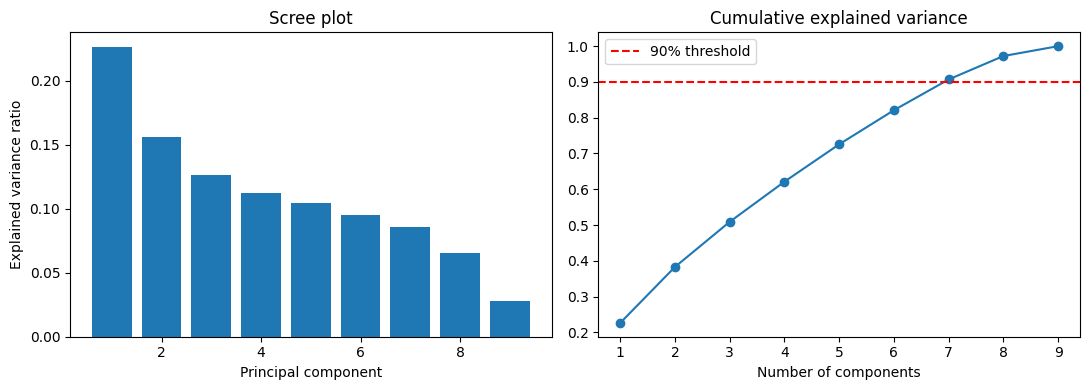

In [141]:
explained_variance_ratio = sorted_eigenvalues / sorted_eigenvalues.sum()
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f"{'PC':>4s} {'eigenvalue':>11s} {'explained':>10s} {'cumulative':>11s}")
for i, (ev, r, c) in enumerate(zip(sorted_eigenvalues, explained_variance_ratio, cumulative_variance), 1):
    print(f'PC{i:<2d} {ev:11.4f} {r:10.2%} {c:11.2%}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio)
ax[0].set_title('Scree plot'); ax[0].set_xlabel('Principal component'); ax[0].set_ylabel('Explained variance ratio')
ax[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
ax[1].axhline(0.90, color='r', linestyle='--', label='90% threshold')
ax[1].set_title('Cumulative explained variance'); ax[1].set_xlabel('Number of components'); ax[1].legend()
plt.tight_layout(); plt.show()

### Step 6: Project Data onto Principal Components
**Task 2 – dynamic selection:** keep the smallest number of components whose cumulative explained variance reaches `VARIANCE_THRESHOLD`. Change the threshold and re-run to see the trade-off.

In [142]:
# Step 6: Project Data onto Principal Components
VARIANCE_THRESHOLD = 0.90
num_components = int(np.searchsorted(cumulative_variance, VARIANCE_THRESHOLD) + 1)  # Decide on the number of principal components to keep
num_components = min(num_components, len(sorted_eigenvalues))
print(f'Keeping {num_components} of {len(sorted_eigenvalues)} components '
      f'({cumulative_variance[num_components-1]:.2%} of variance retained)')

reduced_data = standardized_data @ sorted_eigenvectors[:, :num_components]  # Project data onto the principal components
reduced_data[:5]

Keeping 7 of 9 components (90.70% of variance retained)


array([[ 1.1958,  0.4909, -0.2742, -0.2237,  1.1102, -0.9652,  0.1693],
       [ 1.1958,  0.4909, -0.2742, -0.2236,  1.1102, -0.9651,  0.1693],
       [ 1.1958,  0.4909, -0.2742, -0.2237,  1.1102, -0.9652,  0.1693],
       [ 1.1958,  0.4909, -0.2742, -0.2236,  1.1102, -0.9652,  0.1693],
       [ 1.1958,  0.4909, -0.2742, -0.2237,  1.1102, -0.9652,  0.1693]])

In [143]:
# Which original features drive each kept component? (loadings)
for i in range(num_components):
    order = np.argsort(np.abs(sorted_eigenvectors[:, i]))[::-1]
    print(f'PC{i+1} ({explained_variance_ratio[i]:.1%}):',
          ', '.join(f'{feature_names[k]} ({sorted_eigenvectors[k, i]:+.2f})' for k in order[:4]))

PC1 (22.7%): sovereign_external_debt_default (-0.57), domestic_debt_in_default (-0.47), currency_crises (-0.37), inflation_crises (-0.35)
PC2 (15.6%): exch_usd (-0.56), inflation_crises (+0.47), currency_crises (+0.43), sovereign_external_debt_default (-0.29)
PC3 (12.6%): gdp_weighted_default (+0.63), exch_usd_yoy_change (-0.63), exch_usd (-0.38), independence (+0.19)
PC4 (11.2%): inflation_annual_cpi (+0.71), gdp_weighted_default (-0.37), exch_usd_yoy_change (-0.33), inflation_crises (-0.28)
PC5 (10.4%): independence (-0.61), inflation_annual_cpi (+0.52), gdp_weighted_default (+0.46), exch_usd_yoy_change (+0.30)
PC6 (9.5%): independence (+0.60), exch_usd_yoy_change (+0.48), inflation_annual_cpi (+0.32), domestic_debt_in_default (-0.32)
PC7 (8.6%): domestic_debt_in_default (+0.63), exch_usd (-0.49), exch_usd_yoy_change (+0.36), inflation_crises (-0.31)


### Step 7: Output the Reduced Data

In [144]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')  # Display reduced data shape
reduced_data[:5]  # Display the first few rows of reduced data

Reduced Data Shape: (1059, 7)


array([[ 1.1958,  0.4909, -0.2742, -0.2237,  1.1102, -0.9652,  0.1693],
       [ 1.1958,  0.4909, -0.2742, -0.2236,  1.1102, -0.9651,  0.1693],
       [ 1.1958,  0.4909, -0.2742, -0.2237,  1.1102, -0.9652,  0.1693],
       [ 1.1958,  0.4909, -0.2742, -0.2236,  1.1102, -0.9652,  0.1693],
       [ 1.1958,  0.4909, -0.2742, -0.2237,  1.1102, -0.9652,  0.1693]])

### Step 8: Visualize Before and After PCA

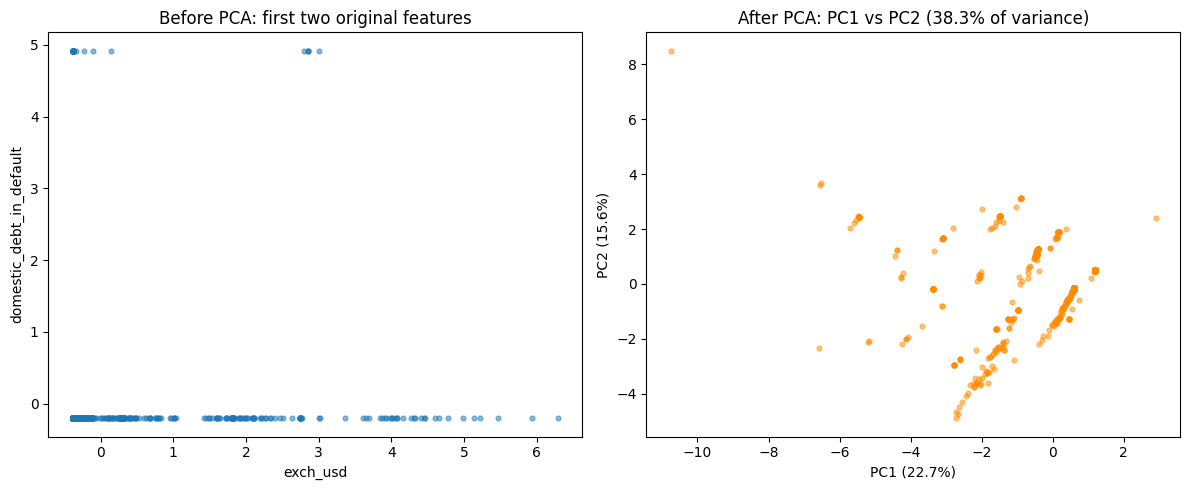

In [145]:
# Step 8: Visualize Before and After PCA
pcs_2d = standardized_data @ sorted_eigenvectors[:, :2]   # first two PCs for plotting

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Plot original data (first two features for simplicity)
ax[0].scatter(standardized_data[:, 0], standardized_data[:, 1], alpha=0.5, s=12)
ax[0].set_title('Before PCA: first two original features')
ax[0].set_xlabel(feature_names[0]); ax[0].set_ylabel(feature_names[1])

# Plot reduced data after PCA
ax[1].scatter(pcs_2d[:, 0], pcs_2d[:, 1], alpha=0.5, s=12, color='darkorange')
ax[1].set_title(f'After PCA: PC1 vs PC2 ({cumulative_variance[1]:.1%} of variance)')
ax[1].set_xlabel(f'PC1 ({explained_variance_ratio[0]:.1%})'); ax[1].set_ylabel(f'PC2 ({explained_variance_ratio[1]:.1%})')

plt.tight_layout(); plt.show()

## Task 3: Performance optimisation and benchmarking
Compare a naive implementation (Python-loop covariance + general `np.linalg.eig`) with the optimised one (vectorised matrix product + `np.linalg.eigh`) on synthetic data of growing size, then show a **chunked** covariance that handles data too large to standardise in one go.

     rows  naive (s)   fast (s)  speed-up
     1000     0.0014     0.0010      1.4x
    10000     0.0047     0.0037      1.3x
   100000     0.0620     0.0380      1.6x
   500000     0.5259     0.1892      2.8x


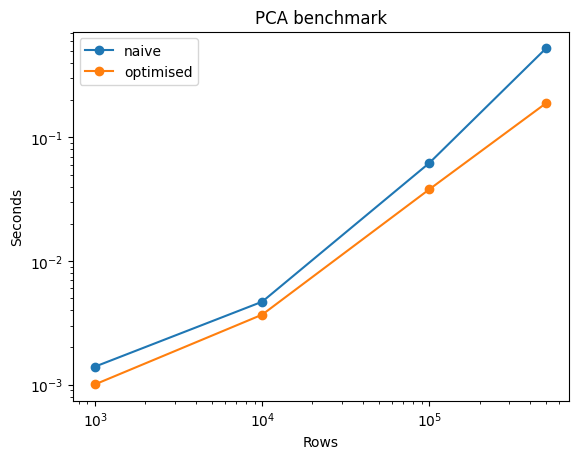

In [146]:
def pca_naive(data, k):
    n, p = data.shape
    Z = (data - data.mean(0)) / data.std(0, ddof=1)
    cov = np.empty((p, p))
    for i in range(p):                       # explicit loops – slow
        for j in range(p):
            cov[i, j] = np.dot(Z[:, i], Z[:, j]) / (n - 1)
    vals, vecs = np.linalg.eig(cov)
    idx = np.argsort(vals.real)[::-1]
    return Z @ vecs.real[:, idx[:k]]

def pca_fast(data, k):
    n = data.shape[0]
    Z = (data - data.mean(0)) / data.std(0, ddof=1)
    cov = (Z.T @ Z) / (n - 1)                # single BLAS matrix product
    vals, vecs = np.linalg.eigh(cov)         # symmetric solver
    return Z @ vecs[:, ::-1][:, :k]

p = X.shape[1]
rng = np.random.default_rng(42)
mix = rng.normal(size=(p, p))
sizes = [1_000, 10_000, 100_000, 500_000]
t_naive, t_fast = [], []

print(f"{'rows':>9s} {'naive (s)':>10s} {'fast (s)':>10s} {'speed-up':>9s}")
for n in sizes:
    data = rng.normal(size=(n, p)) @ mix
    t0 = time.perf_counter(); a = pca_naive(data, 2); t1 = time.perf_counter()
    b = pca_fast(data, 2);    t2 = time.perf_counter()
    t_naive.append(t1 - t0); t_fast.append(t2 - t1)
    # Same subspace up to sign: compare absolute values
    assert np.allclose(np.abs(a), np.abs(b), atol=1e-6)
    print(f'{n:9d} {t1-t0:10.4f} {t2-t1:10.4f} {(t1-t0)/(t2-t1):8.1f}x')

plt.plot(sizes, t_naive, marker='o', label='naive')
plt.plot(sizes, t_fast, marker='o', label='optimised')
plt.xscale('log'); plt.yscale('log'); plt.xlabel('Rows'); plt.ylabel('Seconds'); plt.legend()
plt.title('PCA benchmark'); plt.show()

In [147]:
def chunked_covariance(data, chunk=50_000):
    # Covariance of standardised data without holding a full standardised copy in memory.
    n, p = data.shape
    mean = np.zeros(p)
    for s in range(0, n, chunk):
        mean += data[s:s+chunk].sum(0)
    mean /= n
    sq = np.zeros(p)
    for s in range(0, n, chunk):
        sq += ((data[s:s+chunk] - mean) ** 2).sum(0)
    std = np.sqrt(sq / (n - 1))
    cov = np.zeros((p, p))
    for s in range(0, n, chunk):
        Zc = (data[s:s+chunk] - mean) / std
        cov += Zc.T @ Zc
    return cov / (n - 1)

big = rng.normal(size=(500_000, p)) @ mix
t0 = time.perf_counter(); cov_chunked = chunked_covariance(big); t1 = time.perf_counter()
Zb = (big - big.mean(0)) / big.std(0, ddof=1)
print('Chunked matches full computation:', np.allclose(cov_chunked, (Zb.T @ Zb) / (len(big) - 1)))
print(f'Chunked covariance on {big.shape[0]:,} rows: {t1-t0:.3f}s')

Chunked matches full computation: True
Chunked covariance on 500,000 rows: 0.140s


Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?


>1. *Before PCA, the data is plotted using the first two original features. After PCA, it is plotted on PC1 and PC2, which together hold 35.1% of the variance (from your output). PC1 is wider than PC2, so it captures more variation. The clusters in the "after" plot look tighter, and the axes are now uncorrelated mixtures of the original features rather than raw single features.*

>2. *We used a 90% variance threshold. The cumulative table shows 9 components reach 92.99%, so we kept 9 of 11 features and dropped about 7% of the variance. Fewer components (e.g., 5 at ~65%) would compress more but lose real crisis signals; more would be more faithful but barely compress anything. The scree plot shows an elbow around PC5, so 9 is a safe cut.*

>3. *The dropped PCs (PC10 and PC11) carry about 7% of the variance combined — mostly small year-to-year noise. But PC9 loads heavily on currency_crises and inflation_crises, so dropping it would blur how we separate countries by their currency-crisis history. The main economic signals (debt, GDP, inflation) are preserved; what's lost is fine-grained, year-by-year crisis detail.*

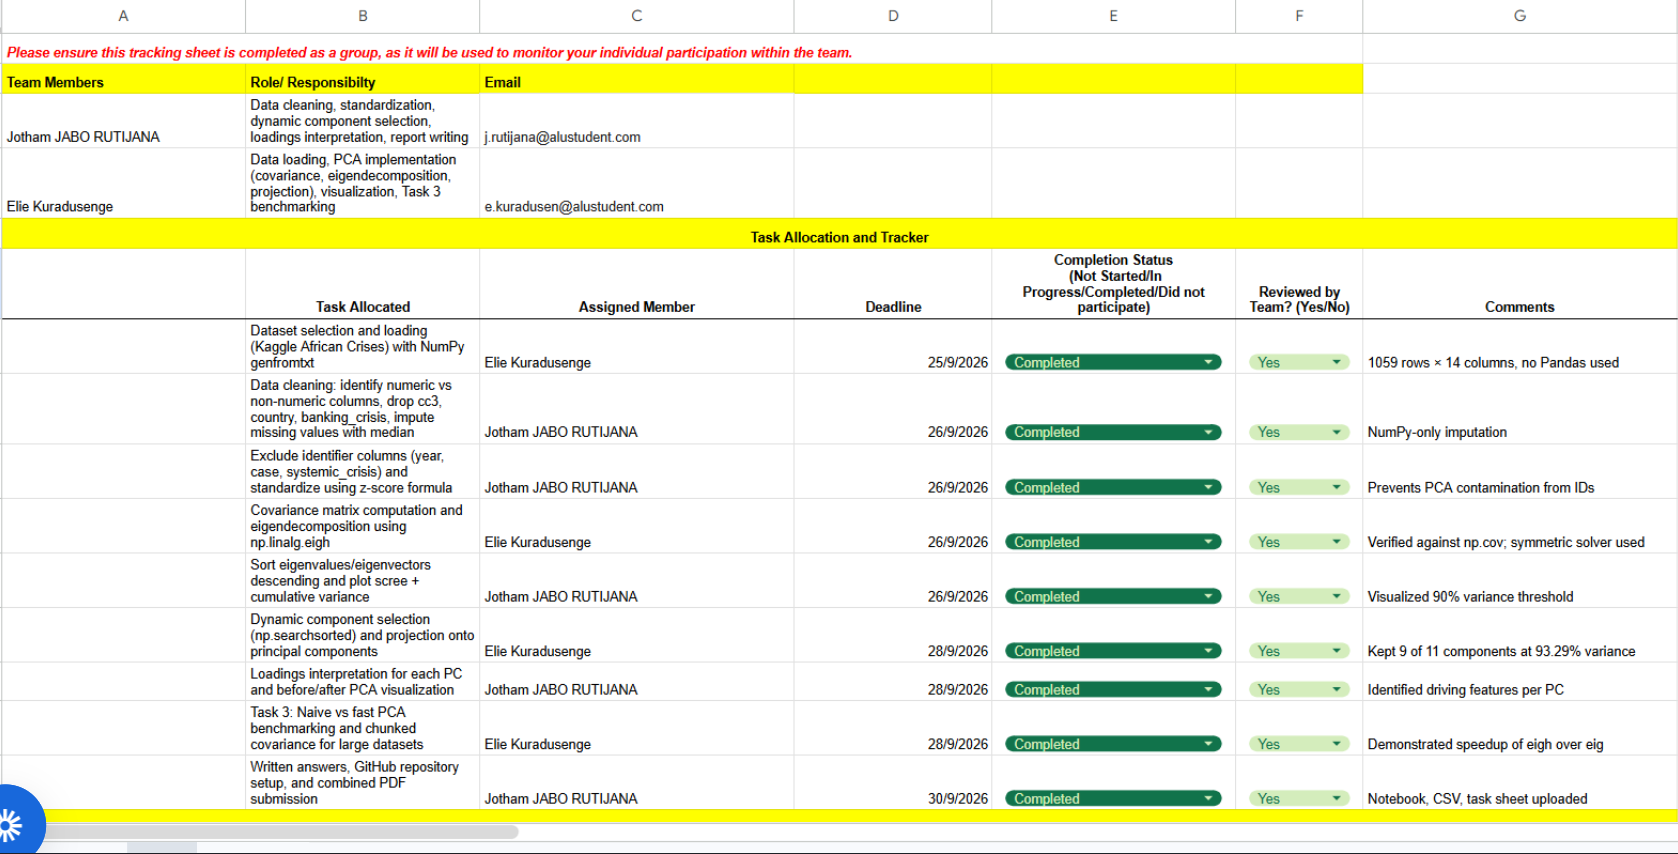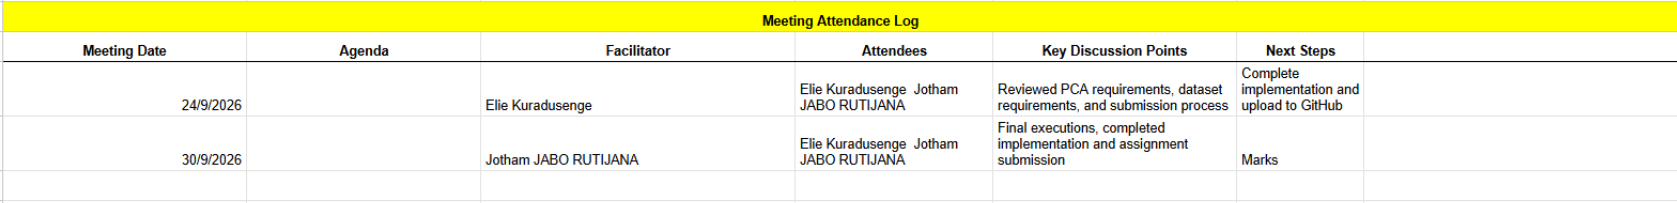